## Assignment 2

#### QUESTION 1 - Blob detection using Laplacian of Gaussian 

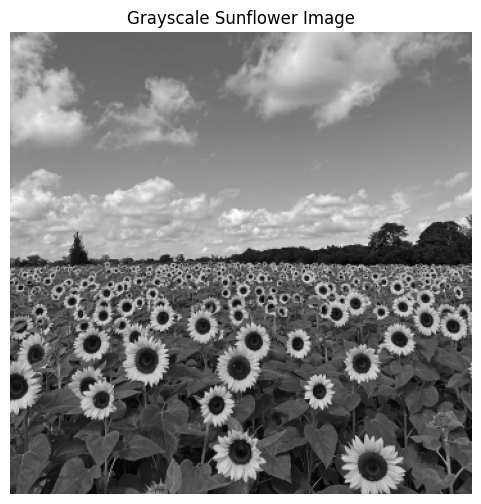

In [14]:
#Question 1
#Imports and Image Reading
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, maximum_filter

# Read the image (downsampled 1/4th to reduce computation)
img_path = r"D:\ACA\sem 5\vision\assignment 2\the_berry_farms_sunflower_field.jpeg"
im = cv.imread(img_path, cv.IMREAD_REDUCED_COLOR_4)

if im is None:
    raise FileNotFoundError("Image not found! Check the path.")

# Convert to grayscale
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY).astype(np.float32) / 255.0

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Sunflower Image")
plt.axis('off')
plt.show()


In [15]:
#Create Scale Space Using Laplacian of Gaussian

def build_log_scale_space(image, min_radius=1, max_radius=10, n_scales=10):
    radii = np.linspace(min_radius, max_radius, n_scales)
    sigmas = radii / np.sqrt(2)

    H, W = image.shape
    scale_space = np.zeros((n_scales, H, W), dtype=np.float32)

    for i, sigma in enumerate(sigmas):
        # Compute normalized Laplacian of Gaussian
        log_resp = gaussian_laplace(image, sigma=sigma)
        scale_space[i] = (sigma ** 2) * np.abs(log_resp)

    return scale_space, sigmas


In [16]:
#Detect Extrema in Scale-Space

def detect_blobs(scale_space, sigmas, threshold_rel=0.05):
    # Find global maximum for thresholding
    max_val = scale_space.max()
    threshold = threshold_rel * max_val

    # 3D non-maximum suppression
    neighborhood = (3, 9, 9)
    max_filtered = maximum_filter(scale_space, size=neighborhood)
    is_max = (scale_space == max_filtered) & (scale_space >= threshold)

    # Extract blob coordinates (scale index, y, x)
    peaks = np.argwhere(is_max)
    blobs = []
    for s_idx, y, x in peaks:
        sigma = sigmas[s_idx]
        radius = np.sqrt(2) * sigma
        resp = scale_space[s_idx, y, x]
        blobs.append({
            'x': int(x),
            'y': int(y),
            'sigma': float(sigma),
            'radius': float(radius),
            'response': float(resp)
        })

    blobs_sorted = sorted(blobs, key=lambda b: b['response'], reverse=True)
    return blobs_sorted


Total blobs detected: 1169
Largest detected blob: {'x': 323, 'y': 207, 'sigma': 2.1213203435596424, 'radius': 3.0, 'response': 0.3990018665790558}
Sigma range used: [0.71 1.41 2.12 2.83 3.54 4.24 4.95 5.66 6.36 7.07]


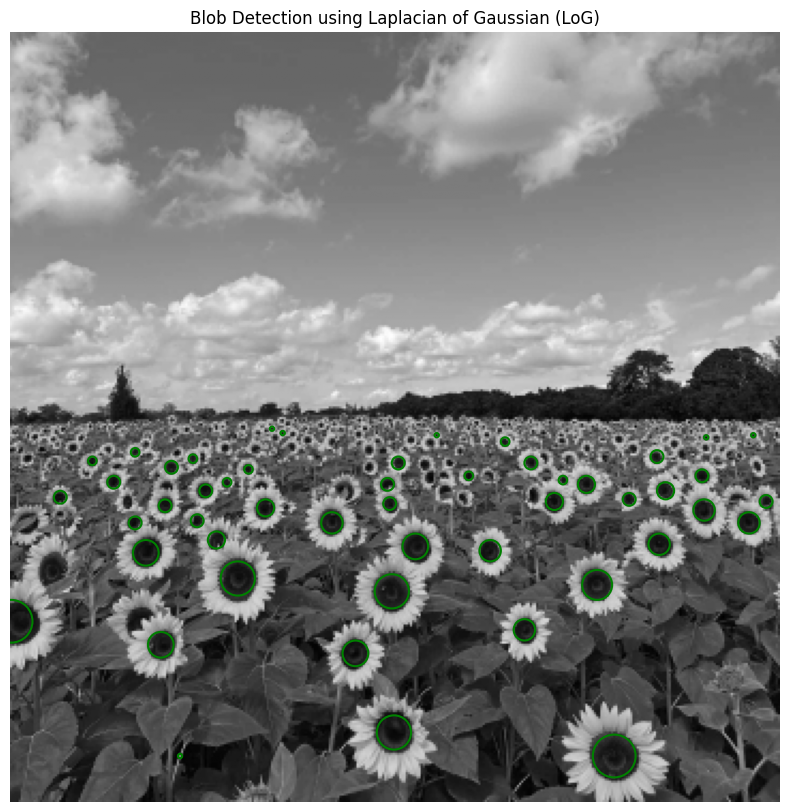

In [ ]:
#Run Blob Detection and Display Results

# Build scale-space
scale_space, sigmas = build_log_scale_space(gray, min_radius=1, max_radius=10, n_scales=10)

# Detect blobs
blobs = detect_blobs(scale_space, sigmas, threshold_rel=0.05)

print(f"Total blobs detected: {len(blobs)}")
if blobs:
    print("Largest detected blob:", blobs[0])
print("Sigma range used:", np.round(sigmas, 2))

# Plot image with top blobs
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(gray, cmap='gray')

for b in blobs[:50]:  # visualize top 50 blobs
    circ = plt.Circle((b['x'], b['y']), b['radius'], color='g', fill=False, linewidth=1.5)
    ax.add_patch(circ)

ax.set_title("Blob Detection using Laplacian of Gaussian (LoG)")
plt.axis('off')
plt.show()
